<a href="https://colab.research.google.com/github/OptimizationExpert/Pyomo/blob/main/domino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ortools
from ortools.sat.python import cp_model # CP-SAT solver
import numpy as np
from random import randint
import random
from math import ceil
import pandas as pd
import matplotlib.pyplot as plt # Data visualization
#plt.rcParams["figure.figsize"] = (15,10)
from matplotlib.patches import Rectangle

import random
import sys
from math import sqrt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 12.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.6 which is incompatibl

In [ ]:

random.seed(0)
N = 45
def print_grid(grid, mask=False):
    print('-' * N)
    for row in grid:
        print(''.join(row))
    print('-' * N)

def print_playable_grid(grid, rows, cols):
    row_padding = max(len(str(i)) for i in rows) + 1
    col_padding = max(len(str(i)) for i in cols) + 1
    row_str = [str(i).rjust(row_padding) for i in rows]
    col_str = [str(i).rjust(col_padding) for i in cols]

    grid_out = [[' ' for i in range(N + 2 + row_padding)] for j in range(N + 2 + col_padding)]

    for i in range(N):
        for j in range(row_padding):
            grid_out[i + col_padding + 1][j] = row_str[i][j]

    for i in range(col_padding):
        for j in range(N):
            grid_out[i][j + row_padding + 1] = col_str[j][i]

    grid_out[col_padding][row_padding] = '┌'
    grid_out[col_padding][N + row_padding + 1] = '┐'
    grid_out[N + col_padding + 1][row_padding] = '└'
    grid_out[N + col_padding + 1][N + row_padding + 1] = '┘'

    for i in range(N):
        grid_out[col_padding + 1 + i][row_padding] = '│'
        grid_out[col_padding + 1 + i][N + row_padding + 1] = '│'
        grid_out[col_padding][row_padding + 1 + i] = '─'
        grid_out[N + col_padding + 1][row_padding + 1 + i] = '─'

    for i in range(N):
        for j in range(N):
            if grid[i][j] in '12|-':
                grid_out[col_padding + 1 + i][row_padding + 1 + j] = ' '
            else:
                grid_out[col_padding + 1 + i][row_padding + 1 + j] = grid[i][j]

    for row in grid_out:
        print(''.join(row))

total = (N * N) // 2
def generate_grid(grid, total):
    missing = random.randint(int(sqrt(max(0, N // 2 - 5))), 2 * N // 3)

    for i in range(total - missing):
        seen = set()
        x, y = random.randint(0, N - 1), random.randint(0, N - 1)
        while True:
            x, y = random.randint(0, N - 1), random.randint(0, N - 1)
            typ = random.randint(0, 1)

            if typ == 0 and x > 0 and grid[x - 1][y] == ' ' and grid[x][y] == ' ':
                grid[x][y] = '|'
                grid[x - 1][y] = '1'
                break

            elif typ == 1 and y < N - 1 and grid[x][y + 1] == ' ' and grid[x][y] == ' ':
                grid[x][y] = '-'
                grid[x][y + 1] = '2'
                break

            seen.add((x, y, typ))
            if len(seen) == N * N * 2:
                print('Failed to generate grid', i, f'{i / (total - missing) * 100:.4f}')
                if i > (total - missing) * 0.94: # 94% filled, pass
                    print("Passed Check 1")
                    return grid, (total - i)

                if N > 30 and i > (total - missing) * 0.91: # 91% filled, pass
                    print("Passed Check 2")
                    return grid, (total - i)

                return None, None

    return grid, missing

while True:
    empty_grid = [[' ' for i in range(N)] for j in range(N)]
    grid, blockers = generate_grid(empty_grid.copy(), total)
    if grid: break

blockers = 2 * blockers + N % 2
data_blocks = []
for i in range(N):
    for j in range(N):
        if grid[i][j] == ' ':
            grid[i][j] = 'X'
            data_blocks.append((j+1,N-i))

print(f'{N} x {N} grid with {blockers} blockers')
print_grid(grid)

rows = []
cols = []
for i in range(N):
    rows.append(sum(int(c) for c in grid[i] if c in '12'))
    cols.append(sum(int(grid[j][i]) for j in range(N) if grid[j][i] in '12'))



Trows = rows
Tcols = cols
print(f'{rows = }')
print(f'{cols = }')

print_playable_grid(grid, rows, cols)
print(data_blocks)

Failed to generate grid 906 90.9639
Failed to generate grid 916 92.4319
Passed Check 2
45 x 45 grid with 193 blockers
---------------------------------------------
-2-2-2X1-2111-2-2-211X-2-2X-2-2-2-2-2X-21-2-2
1111-21|-2|||-2-2-2||-2-2-2-21-2-21111-2|1-2X
||||-2|X-21-2X111-2-2-2-211X1|X-2X||||-2X|-21
1X1-21-2-2|X-2|||11-2-2-2||1|111-211111X1X-2|
|1|-2|1X11-211-21||-2-2-2-2|X|||11|||||1|1111
X|1111|1||-2||1X|X1X1-21-211-2-2||1-2-2|X||||
-2||||1|-2-211|1X1|1|-2|-2||1-2111|1-211111-2
-2X-21|X-2-2||X|1|X|-21111-2|1X|||1|X1|||||-2
-2111|-2-211X11X|-21-2||||11X|1X-2|11|-21-2-2
1X|||11-21||1||-2-2|1-2-2X||11|-2-2||X-2|1X-2
|-2X1||-2|11|1-2-2-2|-2-2-21||-21-2111-21|11X
X1-2|-21-2||X|1-2X-21-2-2-2|X-21|X1|||-2|1||1
1|1-2-2|-2-2-2|-2-21|X111-21-21|X1|1-2111|-2|
|X|-2-2-21-2X1-21X1|-2|||-2|11|-2|X|-2|||1111
11X11-2-2|1-2|-2|1|1-2-2-211||-2X-2-2-2-2||||
||1||111-2|-21X-2|1|X-21-2||X11-2-21X11-2-2-2
11|-2|||X-211|-2-2|-2-2|X1-21||1-2X|1||1-2111
||1-2-2-2-2||1111-21-21-2|-2|-2|111X|-2|1X|||
X1|-21-2

In [ ]:
cells = {(i,j):0 for i in range(1,N+1) for j in range(1,1+N) if (i,j) not in data_blocks}
print(cells)

{(1, 1): 0, (1, 3): 0, (1, 4): 0, (1, 5): 0, (1, 6): 0, (1, 7): 0, (1, 8): 0, (1, 9): 0, (1, 11): 0, (1, 12): 0, (1, 13): 0, (1, 14): 0, (1, 15): 0, (1, 16): 0, (1, 17): 0, (1, 18): 0, (1, 19): 0, (1, 21): 0, (1, 22): 0, (1, 23): 0, (1, 24): 0, (1, 25): 0, (1, 26): 0, (1, 28): 0, (1, 29): 0, (1, 30): 0, (1, 31): 0, (1, 32): 0, (1, 33): 0, (1, 35): 0, (1, 36): 0, (1, 37): 0, (1, 38): 0, (1, 39): 0, (1, 41): 0, (1, 42): 0, (1, 43): 0, (1, 44): 0, (1, 45): 0, (2, 1): 0, (2, 2): 0, (2, 3): 0, (2, 5): 0, (2, 6): 0, (2, 7): 0, (2, 8): 0, (2, 9): 0, (2, 10): 0, (2, 11): 0, (2, 12): 0, (2, 13): 0, (2, 15): 0, (2, 16): 0, (2, 18): 0, (2, 19): 0, (2, 20): 0, (2, 21): 0, (2, 22): 0, (2, 24): 0, (2, 26): 0, (2, 27): 0, (2, 28): 0, (2, 29): 0, (2, 30): 0, (2, 31): 0, (2, 33): 0, (2, 34): 0, (2, 35): 0, (2, 37): 0, (2, 38): 0, (2, 39): 0, (2, 40): 0, (2, 41): 0, (2, 43): 0, (2, 44): 0, (2, 45): 0, (3, 1): 0, (3, 2): 0, (3, 4): 0, (3, 5): 0, (3, 6): 0, (3, 7): 0, (3, 8): 0, (3, 9): 0, (3, 10): 0, (3,

In [ ]:
model = cp_model.CpModel()
solver = cp_model.CpSolver()

rows = [i for i in range(1,N+1)]
cols = [i for i in range(1,N+1)]


Uv = {(i,j):model.NewBoolVar(f"Vertical_{i}_{j}") for (i,j) in cells if (i,j) not in data_blocks and (i,j+1) not in data_blocks and (i,j+1) in cells}
Uh = {(i,j):model.NewBoolVar(f"Horisontal_{i}_{j}") for (i,j) in cells if (i,j) not in data_blocks and (i+1,j) not in data_blocks and (i+1,j) in cells}

for (i,j),v in Uv.items():
  if (i,j) in Uh:
    model.add_at_most_one(Uv[i,j],Uh[i,j])
  if (i,j+1) in Uh:
    model.add_at_most_one(Uv[i,j],Uh[i,j+1])
  if (i-1,j) in Uh:
    model.add_at_most_one(Uv[i,j],Uh[i-1,j])
  if (i-1,j+1) in Uh:
    model.add_at_most_one(Uv[i,j],Uh[i-1,j+1])
  if (i,j+1) in Uv:
    model.add_at_most_one(Uv[i,j],Uv[i,j+1])

for (i,j),v in Uh.items():
  if (i-1,j) in Uh:
    model.add_at_most_one(Uh[i,j],Uh[i-1,j])

for c in cols:
  v_sum =sum(Uv[c,r] for r in rows if (c,r) in Uv)
  h_sum =2*sum(Uh[c-1,r] for r in rows if (c-1,r) in Uh )
  model.Add(v_sum +h_sum == Tcols[c-1])

for r in rows:
  v_sum =sum(Uv[c,r-1] for c in cols if (c,r-1) in Uv)
  h_sum =2*sum(Uh[c,r] for c in cols if (c,r) in Uh)
  model.Add(v_sum+h_sum == Trows[N-r])

for (i,j) in cells:
  expr = []
  if (i,j) in Uv:
    expr.append(Uv[i,j])
  if (i,j) in Uh:
    expr.append(Uh[i,j])
  if (i-1,j) in Uh:
    expr.append(Uh[i-1,j])
  if (i,j-1) in Uv:
    expr.append(Uv[i,j-1])
  model.add_exactly_one(expr)

expr = [v for v in Uv.values()]
expr = [v for v in Uh.values()]

model.maximize(sum(expr))
result= solver.Solve(model)
print(solver.StatusName(result))


OPTIMAL


45
1 41 0 28


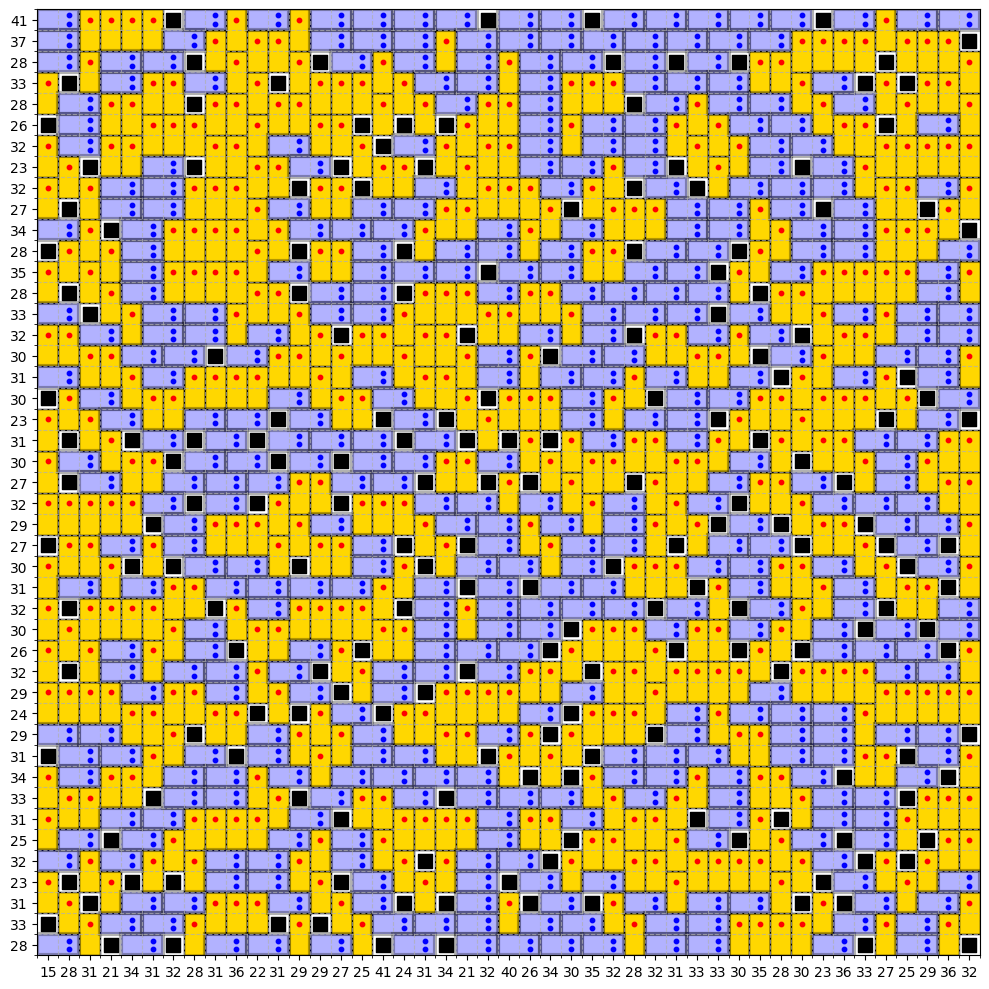

In [ ]:
black_size = 100
bulletsize = 10
plt.figure(figsize=(10,10))
for (i,j) in data_blocks:
  plt.scatter(i,j,marker='s',s=black_size, c='k')

for (i,j),v in Uv.items():
  if solver.value(v)>0:
    rect = Rectangle((i-0.5, j-0.5), 1, 2, edgecolor='black', facecolor='gold')
    plt.gca().add_patch(rect)
    plt.scatter(i,j+1,s=bulletsize,color='red')

for (i,j),v in Uh.items():
  if solver.value(v)>0:
    rect = Rectangle((i-0.5, j-0.5), 2, 1, edgecolor='k', facecolor='b', alpha=0.3, linewidth=3)
    plt.gca().add_patch(rect)
    plt.scatter(i+1,j+0.2,s=bulletsize,color='b')
    plt.scatter(i+1,j-0.2,s=bulletsize,color='b')

#plt.grid(zorder=-2)
# Set limits
plt.xlim(0.5, N+0.5)
plt.ylim(0.5, N+0.5)
print(N)
plt.tight_layout()

for r in [1]:
  v_sum =sum(Uv[c,r-1] for c in cols if (c,r-1) in Uv)
  h_sum =2*sum(Uh[c,r] for c in cols if (c,r) in Uh)
  print(r,Trows[r-1], solver.value(v_sum) , solver.value(h_sum))
  # model.Add(v_sum+h_sum == Trows[r-1])
Trows_rev = Trows.copy()
Trows_rev.reverse()
plt.yticks(range(1,1+N),Trows_rev)

plt.gca().set_xticks(np.arange(0.5, N+1.5, 1), minor=True)
plt.grid(which='minor', linestyle='--', alpha=0.7)
plt.gca().set_yticks(np.arange(0.5, N+1.5, 1), minor=True)
plt.grid(which='minor', linestyle='--', alpha=0.7)

plt.xticks(range(1,1+N),Tcols)
plt.show()

45
1 41 0 28


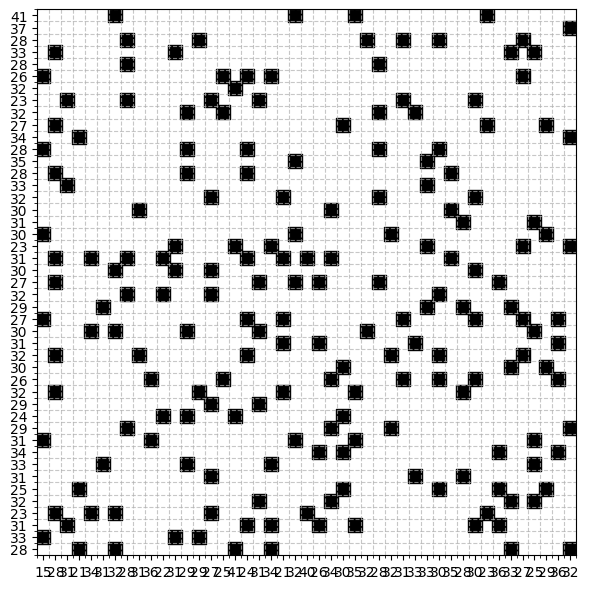

In [ ]:

plt.figure(figsize=(6,6))
for (i,j) in data_blocks:
  plt.scatter(i,j,marker='s',s=black_size, c='k')


# Set limits
plt.xlim(00.5, N+0.5)
plt.ylim(0.5, N+0.5)
print(N)
plt.tight_layout()

for r in [1]:
  v_sum =sum(Uv[c,r-1] for c in cols if (c,r-1) in Uv)
  h_sum =2*sum(Uh[c,r] for c in cols if (c,r) in Uh)
  print(r,Trows[r-1], solver.value(v_sum) , solver.value(h_sum))
  # model.Add(v_sum+h_sum == Trows[r-1])
Trows_rev = Trows.copy()
Trows_rev.reverse()
plt.yticks(range(1,1+N),Trows_rev)

plt.gca().set_xticks(np.arange(0.5, N+1.5, 1), minor=True)
plt.grid(which='minor', linestyle='--', alpha=0.7)
plt.gca().set_yticks(np.arange(0.5, N+1.5, 1), minor=True)
plt.grid(which='minor', linestyle='--', alpha=0.7)

plt.xticks(range(1,1+N),Tcols)
plt.show()